In [2]:
from load_sim_data import *
from load_shp import *
from sim_eval_pkg import *

Updated on 2026-03-04


In [3]:
feature_name_dict={'μ_EM_ROOF': r'$μ_{EMr}$',
 'σ_EM_ROOF': r'$σ_{EMr}$',
 'μ_EM_IMPROAD': r'$μ_{EMir}$',
 'σ_EM_IMPROAD': r'$σ_{EMir}$',
 'μ_EM_PERROAD': r'$μ_{EMpr}$',
 'σ_EM_PERROAD': r'$σ_{EMpr}$',
 'μ_EM_WALL': r'$μ_{EMw}$',
 'σ_EM_WALL': r'$σ_{EMw}$',
 'μ_ALB_ROOF_DIR': r'$μ_{ALBr}$',
 'σ_ALB_ROOF_DIR': r'$σ_{ALBr}$',
 'μ_ALB_IMPROAD_DIR': r'$μ_{ALBir}$',
 'σ_ALB_IMPROAD_DIR': r'$σ_{ALBir}$',
 'μ_ALB_PERROAD_DIR': r'$μ_{ALBpr}$',
 'σ_ALB_PERROAD_DIR': r'$σ_{ALBpr}$',
 'μ_ALB_WALL_DIR': r'$μ_{ALBw}$',
 'σ_ALB_WALL_DIR': r'$σ_{ALBw}$',
 'μ_CANYON_HWR': r'$μ_{HWR}$',
 'σ_CANYON_HWR': r'$σ_{HWR}$',
 'μ_HT_ROOF': r'$μ_{HT}$',
 'σ_HT_ROOF': r'$σ_{HT}$',
 'μ_WTLUNIT_ROOF': r'$μ_{WTR}$',
 'σ_WTLUNIT_ROOF': r'$σ_{WTR}$',
 'μ_WTROAD_PERV': r'$μ_{WTP}$',
 'σ_WTROAD_PERV': r'$σ_{WTP}$'
}

feature_label_map = {
    k.replace("μ_", "mu_").replace("σ_", "sigma_"): v
    for k, v in feature_name_dict.items()
}

In [4]:
# Basic configs
CONUS_BOUNDS = {
    "lat_min": 24.0,
    "lat_max": 50.0,
    "lon_min": -125.0,
    "lon_max": -66.0,
}

WINDOW_SIZE_LAT = 2.0
WINDOW_SIZE_LON = 2.0

# fixed window
STRIDE_LAT = 2.0
STRIDE_LON = 2.0
# sliding window
# STRIDE_LAT = 1.0
# STRIDE_LON = 1.0

INCLUDE_PARTIAL_WINDOWS = False

ROLLING_SIZES = {
    "1/32deg": 96,
    "14km": 24,
    "0.25deg": 12,
    "1deg": 3,
}

VALUE_FILTERS = {
    "bowen": (-50.0, 200.0),
    "netrad": (-500.0, 1500.0),
}

SUPERVISED_ABS_CORR_THRESHOLD = 0.08
SUPERVISED_MIN_FEATURES = 6
SUPERVISED_TOP_K = None

SURFDATA_FILE = "/glade/work/yifanc17/02_data/cesmdata/surfdata/CONUS_3p75/surfdata_CONUS_1d32deg_hist_usurf_adjusted_pct_2015_16pfts_TEST_THR_latlon_c25521.nc"

In [5]:
def to_lon180_da(da):
    if "lon" in da.coords and float(da.lon.max()) > 180:
        da = da.assign_coords(lon=((da.lon + 180) % 360) - 180).sortby("lon")
    return da


def to_lon180_ds(ds):
    if "lon" in ds.coords and float(ds.lon.max()) > 180:
        ds = ds.assign_coords(lon=((ds.lon + 180) % 360) - 180).sortby("lon")
    return ds


def build_conus_windows(conus_bounds, window_lat, window_lon, stride_lat, stride_lon,include_partial=False):
    lat_min = float(conus_bounds["lat_min"])
    lat_max = float(conus_bounds["lat_max"])
    lon_min = float(conus_bounds["lon_min"])
    lon_max = float(conus_bounds["lon_max"])

    windows = []
    iwin = 0

    lat0 = lat_min
    while lat0 < lat_max:
        lat1 = lat0 + window_lat
        if lat1 > lat_max and not include_partial:
            break
        lat1 = min(lat1, lat_max)

        lon0 = lon_min
        while lon0 < lon_max:
            lon1 = lon0 + window_lon
            if lon1 > lon_max and not include_partial:
                break
            lon1 = min(lon1, lon_max)

            if lat1 > lat0 and lon1 > lon0:
                iwin += 1
                windows.append(
                    {
                        "window_id": f"W{iwin:05d}",
                        "lat_min": lat0,
                        "lat_max": lat1,
                        "lon_min": lon0,
                        "lon_max": lon1,
                        "lat_center": 0.5 * (lat0 + lat1),
                        "lon_center": 0.5 * (lon0 + lon1),
                    }
                )

            lon0 += stride_lon
        lat0 += stride_lat

    out = pd.DataFrame(windows)
    mode = "fixed" if (np.isclose(window_lat, stride_lat) and np.isclose(window_lon, stride_lon)) else "sliding"
    print(f"Built {out.shape[0]} {mode} CONUS windows ({window_lat}x{window_lon} deg, stride {stride_lat}x{stride_lon} deg)")
    return out

def window_variability_metric(da_window, value_range, min_valid_cells=4):
    da = da_window.where(np.isfinite(da_window))

    if value_range is not None:
        lo, hi = value_range
        da = da.where((da >= lo) & (da <= hi))

    valid_count = int(da.count().values) if da.size > 0 else 0
    if valid_count < min_valid_cells:
        return np.nan

    value = float(da.std(skipna=True))
    if np.isnan(value) or np.isinf(value):
        return np.nan
    return value


def calculate_window_info_loss(var_1deg, var_025deg, var_14km, var_1d32deg, windows_df, value_range, min_valid_cells=4):
    var_data = {
        "1deg": to_lon180_da(var_1deg),
        "0.25deg": to_lon180_da(var_025deg),
        "14km": to_lon180_da(var_14km),
        "1/32deg": to_lon180_da(var_1d32deg),
    }

    resolutions = ["1/32deg", "14km", "0.25deg", "1deg"]
    scale_ratios = np.array([1, 4, 8, 32], dtype=float)

    rows = []
    dropped_ref_invalid = 0

    for _, win in windows_df.iterrows():
        bounds = {
            "lat": slice(win["lat_min"], win["lat_max"]),
            "lon": slice(win["lon_min"], win["lon_max"]),
        }

        std_values = []
        for res in resolutions:
            da = var_data[res].sel(lat=bounds["lat"], lon=bounds["lon"])
            metric = window_variability_metric(
                da,
                value_range=value_range,
                min_valid_cells=min_valid_cells,
            )
            std_values.append(metric)

        if np.isnan(std_values[0]) or std_values[0] <= 0:
            dropped_ref_invalid += 1
            continue

        std_values = np.asarray(std_values, dtype=float)
        std_ratios = std_values / std_values[0]
        info_loss = (1.0 - std_ratios) * 100.0

        valid_idx = np.where(~np.isnan(std_ratios))[0]
        beta = np.nan
        r_squared = np.nan

        if len(valid_idx) >= 3:
            x = np.log(scale_ratios[valid_idx][1:])
            y = np.log(std_ratios[valid_idx][1:])
            finite = ~(np.isnan(x) | np.isnan(y) | np.isinf(x) | np.isinf(y))
            if np.sum(finite) >= 2:
                slope, intercept, r_value, p_value, std_err = stats.linregress(x[finite], y[finite])
                beta = float(slope)
                r_squared = float(r_value ** 2)

        rows.append(
            {
                "window_id": win["window_id"],
                "lat_min": win["lat_min"],
                "lat_max": win["lat_max"],
                "lon_min": win["lon_min"],
                "lon_max": win["lon_max"],
                "lat_center": win["lat_center"],
                "lon_center": win["lon_center"],
                "std_1d32": std_values[0],
                "std_14km": std_values[1],
                "std_025deg": std_values[2],
                "std_1deg": std_values[3],
                "ratio_14km": std_ratios[1],
                "ratio_025deg": std_ratios[2],
                "ratio_1deg": std_ratios[3],
                "info_loss_14km": info_loss[1],
                "info_loss_025deg": info_loss[2],
                "info_loss_1deg": info_loss[3],
                "avg_info_loss": np.nanmean(info_loss[1:]),
                "beta": beta,
                "r_squared": r_squared,
            }
        )

    out = pd.DataFrame(rows)
    print(
        f"Built window-level info-loss table: {out.shape[0]} samples x {out.shape[1]} columns "
        f"(dropped ref-invalid windows: {dropped_ref_invalid})"
    )
    return out


def select_urban_layer(da, var_name):
    if "numurbl" in da.dims:
        da = da.sel(numurbl=2)
    if "ALB" in var_name and "numrad" in da.dims:
        da = da.sel(numrad=0)
    return da


def extract_driver_window_statistics(surfdata_file, windows_df):
    driver_vars = [
        "EM_ROOF",
        "EM_IMPROAD",
        "EM_PERROAD",
        "EM_WALL",
        "ALB_ROOF_DIR",
        "ALB_IMPROAD_DIR",
        "ALB_PERROAD_DIR",
        "ALB_WALL_DIR",
        "CANYON_HWR",
        "HT_ROOF",
        "WTLUNIT_ROOF",
        "WTROAD_PERV",
    ]

    ds = to_lon180_ds(xr.open_dataset(surfdata_file))
    available = [v for v in driver_vars if v in ds.variables]
    missing = [v for v in driver_vars if v not in ds.variables]

    print(f"Driver vars found ({len(available)}): {available}")
    if missing:
        print(f"Missing driver vars ({len(missing)}): {missing}")

    rows = []
    for _, win in windows_df.iterrows():
        bounds = {
            "lat": slice(win["lat_min"], win["lat_max"]),
            "lon": slice(win["lon_min"], win["lon_max"]),
        }

        row = {
            "window_id": win["window_id"],
            "lat_min": win["lat_min"],
            "lat_max": win["lat_max"],
            "lon_min": win["lon_min"],
            "lon_max": win["lon_max"],
            "lat_center": win["lat_center"],
            "lon_center": win["lon_center"],
        }

        for var_name in available:
            da = select_urban_layer(ds[var_name], var_name)
            da_win = da.sel(lat=bounds["lat"], lon=bounds["lon"])
            row[f"mu_{var_name}"] = float(da_win.mean(skipna=True))
            row[f"sigma_{var_name}"] = float(da_win.std(skipna=True))

        rows.append(row)

    ds.close()

    out = pd.DataFrame(rows)
    print(f"Built window-level driver table: {out.shape[0]} samples x {out.shape[1]} columns")
    return out


def build_pca_dataset(info_loss_df, driver_df, target_col="avg_info_loss", min_urban_fraction=None):
    merged = info_loss_df.merge(
        driver_df.drop(columns=["lat_min", "lat_max", "lon_min", "lon_max", "lat_center", "lon_center"]),
        on="window_id",
        how="inner",
    )

    merged = merged.replace([np.inf, -np.inf], np.nan)
    merged = merged.dropna(subset=[target_col])

    if min_urban_fraction is not None and "mu_WTLUNIT_ROOF" in merged.columns:
        before = merged.shape[0]
        merged = merged[merged["mu_WTLUNIT_ROOF"] >= min_urban_fraction].copy()
        print(f"Urban filter (mu_WTLUNIT_ROOF >= {min_urban_fraction}): {before} -> {merged.shape[0]}")

    print(f"Final PCA/PCR dataset: {merged.shape[0]} samples x {merged.shape[1]} columns")
    return merged


def feature_columns(df, target_col):
    meta_cols = {
        "window_id",
        "lat_min",
        "lat_max",
        "lon_min",
        "lon_max",
        "lat_center",
        "lon_center",
        "std_1d32",
        "std_14km",
        "std_025deg",
        "std_1deg",
        "ratio_14km",
        "ratio_025deg",
        "ratio_1deg",
        "info_loss_14km",
        "info_loss_025deg",
        "info_loss_1deg",
        "avg_info_loss",
        "beta",
        "r_squared",
    }
    return [c for c in df.columns if c not in meta_cols and c != target_col]


def compare_br_nr_targets(pca_df_bowen, pca_df_netrad, target_col="avg_info_loss"):
    merged = pca_df_bowen[["window_id", target_col]].merge(
        pca_df_netrad[["window_id", target_col]],
        on="window_id",
        suffixes=("_br", "_nr"),
        how="inner",
    )
    corr = float(np.corrcoef(merged[f"{target_col}_br"], merged[f"{target_col}_nr"])[0, 1])
    print(f"BR vs NR target correlation ({target_col}): {corr:.3f} from {merged.shape[0]} shared windows")
    return corr, merged


def compute_pls_vip(pls_model):
    T = pls_model.x_scores_
    W = pls_model.x_weights_
    Q = np.ravel(pls_model.y_loadings_)

    p, h = W.shape
    s = np.array([np.sum(T[:, a] ** 2) * (Q[a] ** 2) for a in range(h)], dtype=float)
    total_s = float(np.sum(s))
    if total_s <= 0:
        return np.zeros(p, dtype=float)

    w_norm2 = np.sum(W ** 2, axis=0)
    w_norm2[w_norm2 == 0] = np.nan
    weighted = (W ** 2 / w_norm2) @ s
    weighted = np.nan_to_num(weighted, nan=0.0)

    vip = np.sqrt(p * weighted / total_s)
    return vip


def perform_pls_cv_analysis(df, target_col="avg_info_loss", max_components=12, n_splits=5, random_state=42):
    feature_cols = feature_columns(df, target_col)
    X = df[feature_cols].values
    y = df[target_col].values

    nmax = min(max_components, X.shape[0] - 1, X.shape[1])
    cv = KFold(n_splits=min(n_splits, X.shape[0]), shuffle=True, random_state=random_state)

    rows = []
    for ncomp in range(1, nmax + 1):
        model = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", StandardScaler()),
                ("pls", PLSRegression(n_components=ncomp, scale=False)),
            ]
        )

        r2 = cross_val_score(model, X, y, cv=cv, scoring="r2")
        rmse = np.sqrt(-cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error"))

        rows.append(
            {
                "n_components": ncomp,
                "cv_r2_mean": float(np.mean(r2)),
                "cv_r2_std": float(np.std(r2)),
                "cv_rmse_mean": float(np.mean(rmse)),
                "cv_rmse_std": float(np.std(rmse)),
            }
        )

    cv_table = pd.DataFrame(rows)
    best_n = int(cv_table.loc[cv_table["cv_r2_mean"].idxmax(), "n_components"])

    best_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("pls", PLSRegression(n_components=best_n, scale=False)),
        ]
    )
    best_model.fit(X, y)

    pls = best_model.named_steps["pls"]
    x_scores = pls.x_scores_
    x_loadings = pls.x_loadings_
    coef = np.ravel(pls.coef_)
    vip = compute_pls_vip(pls)

    coef_df = pd.DataFrame(
        {
            "feature": feature_cols,
            "coef_std": coef,
            "abs_coef_std": np.abs(coef),
            "vip": vip,
        }
    ).sort_values("vip", ascending=False)

    print("PLS complete")
    print(f"  samples: {X.shape[0]}")
    print(f"  features: {X.shape[1]}")
    print(f"  best n_components by CV R2: {best_n}")
    print(cv_table)

    return {
        "best_model": best_model,
        "best_n_components": best_n,
        "cv_table": cv_table,
        "feature_cols": feature_cols,
        "x_scores": x_scores,
        "x_loadings": x_loadings,
        "coef_df": coef_df,
        "target_col": target_col,
        "data_df": df.copy(),
    }

In [6]:
def plot_pls_biplot(pls_results, target_label, top_n_loadings=10, loading_scale=6.0, figsize=(12, 9), feature_label_map=None, save_path=None):
    x_scores = pls_results["x_scores"]
    x_loadings = pls_results["x_loadings"]
    feature_cols = pls_results["feature_cols"]
    df = pls_results["data_df"].copy()
    target_col = pls_results["target_col"]

    df["LV1"] = x_scores[:, 0]
    df["LV2"] = x_scores[:, 1]

    fig, ax = plt.subplots(figsize=figsize)
    sc = ax.scatter(
        df["LV1"].values,
        df["LV2"].values,
        c=df[target_col].values,
        cmap="RdYlBu_r",
        s=25,
        alpha=0.75,
        edgecolor="none",
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.8, fraction=0.03, anchor=(0.0, 0.5))
    cbar.set_label(f"{target_label} info loss (%)",fontsize=18)
    cbar.ax.tick_params(labelsize=16)
    
    # use VIP to select arrows to be displayed
    coef_df = pls_results["coef_df"].copy()
    top_features = coef_df.sort_values("vip", ascending=False).head(top_n_loadings)["feature"].tolist()
    feat_to_idx = {f: i for i, f in enumerate(feature_cols)}
    top_idx = [feat_to_idx[f] for f in top_features if f in feat_to_idx]

    for idx in top_idx:
        l1 = float(x_loadings[idx, 0])
        l2 = float(x_loadings[idx, 1])
        feature = feature_cols[idx]
        label = feature_label_map.get(feature, feature) if feature_label_map else feature

        ax.arrow(
            0,
            0,
            l1 * loading_scale,
            l2 * loading_scale,
            head_width=0.08,
            head_length=0.12,
            fc="black",
            ec="black",
            linewidth=1.0,
            alpha=0.85,
            length_includes_head=True,
        )
        ax.text(
            l1 * loading_scale * 1.1,
            l2 * loading_scale * 1.1,
            label,
            fontsize=20,
            ha="center",
            va="center",
            color="black",
        )

    ax.axhline(0, color="gray", lw=0.8, alpha=0.7)
    ax.axvline(0, color="gray", lw=0.8, alpha=0.7)
    ax.grid(alpha=0.25, linestyle="--")
    ax.set_xlabel("T1",fontsize=20)
    ax.set_ylabel("T2",fontsize=20)
    ax.tick_params(axis="both", which="major", labelsize=16)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

In [7]:
# 1) Build CONUS windows
windows_df = build_conus_windows(
    CONUS_BOUNDS,
    window_lat=WINDOW_SIZE_LAT,
    window_lon=WINDOW_SIZE_LON,
    stride_lat=STRIDE_LAT,
    stride_lon=STRIDE_LON,
    include_partial=INCLUDE_PARTIAL_WINDOWS,
)

# 2) Compute window-level info loss for BR and NR
bowen_info_df = calculate_window_info_loss(
    bowen_ratio_1deg,
    bowen_ratio_025deg,
    bowen_ratio_14km,
    bowen_ratio_1d32deg,
    windows_df,
    value_range=VALUE_FILTERS["bowen"],
)

netrad_info_df = calculate_window_info_loss(
    net_radiation_1deg,
    net_radiation_025deg,
    net_radiation_14km,
    net_radiation_1d32deg,
    windows_df,
    value_range=VALUE_FILTERS["netrad"],
)

# 3) Compute window-level UCP mu/sigma from 3.75km surfdata
driver_df = extract_driver_window_statistics(SURFDATA_FILE, windows_df)

# 4) Build PCA dataset
pca_df_bowen = build_pca_dataset(
    bowen_info_df,
    driver_df,
    target_col="avg_info_loss",
    min_urban_fraction=0,
)
pca_df_netrad = build_pca_dataset(
    netrad_info_df,
    driver_df,
    target_col="avg_info_loss",
    min_urban_fraction=0,
)

print(f"BR info-loss samples: {bowen_info_df.shape[0]}")
print(f"NR info-loss samples: {netrad_info_df.shape[0]}")
print(f"BR PCA/PCR samples (after merge/filter): {pca_df_bowen.shape[0]}")
print(f"NR PCA/PCR samples (after merge/filter): {pca_df_netrad.shape[0]}")

Built 377 fixed CONUS windows (2.0x2.0 deg, stride 2.0x2.0 deg)
Built window-level info-loss table: 255 samples x 20 columns (dropped ref-invalid windows: 122)
Built window-level info-loss table: 255 samples x 20 columns (dropped ref-invalid windows: 122)
Driver vars found (12): ['EM_ROOF', 'EM_IMPROAD', 'EM_PERROAD', 'EM_WALL', 'ALB_ROOF_DIR', 'ALB_IMPROAD_DIR', 'ALB_PERROAD_DIR', 'ALB_WALL_DIR', 'CANYON_HWR', 'HT_ROOF', 'WTLUNIT_ROOF', 'WTROAD_PERV']
Built window-level driver table: 377 samples x 31 columns
Urban filter (mu_WTLUNIT_ROOF >= 0): 251 -> 251
Final PCA/PCR dataset: 251 samples x 44 columns
Urban filter (mu_WTLUNIT_ROOF >= 0): 251 -> 251
Final PCA/PCR dataset: 251 samples x 44 columns
BR info-loss samples: 255
NR info-loss samples: 255
BR PCA/PCR samples (after merge/filter): 251
NR PCA/PCR samples (after merge/filter): 251


PLS complete
  samples: 251
  features: 24
  best n_components by CV R2: 8
    n_components  cv_r2_mean  cv_r2_std  cv_rmse_mean  cv_rmse_std
0              1    0.079043   0.122176     17.657332     0.846716
1              2    0.123059   0.191235     17.137803     0.966776
2              3    0.149274   0.152760     16.915873     0.752942
3              4    0.144363   0.191401     16.913940     1.037600
4              5    0.136323   0.192375     17.000017     1.095092
5              6    0.141369   0.177380     16.965213     0.968059
6              7    0.155525   0.171644     16.828104     0.921224
7              8    0.160575   0.171481     16.773955     0.844321
8              9    0.134502   0.176477     17.031300     0.797825
9             10    0.132981   0.188469     17.029768     0.878666
10            11    0.143477   0.199649     16.906139     0.976327
11            12    0.135110   0.211064     16.974902     1.054125
PLS complete
  samples: 251
  features: 24
  best n_co

(<Figure size 1200x900 with 2 Axes>, <Axes: xlabel='T1', ylabel='T2'>)

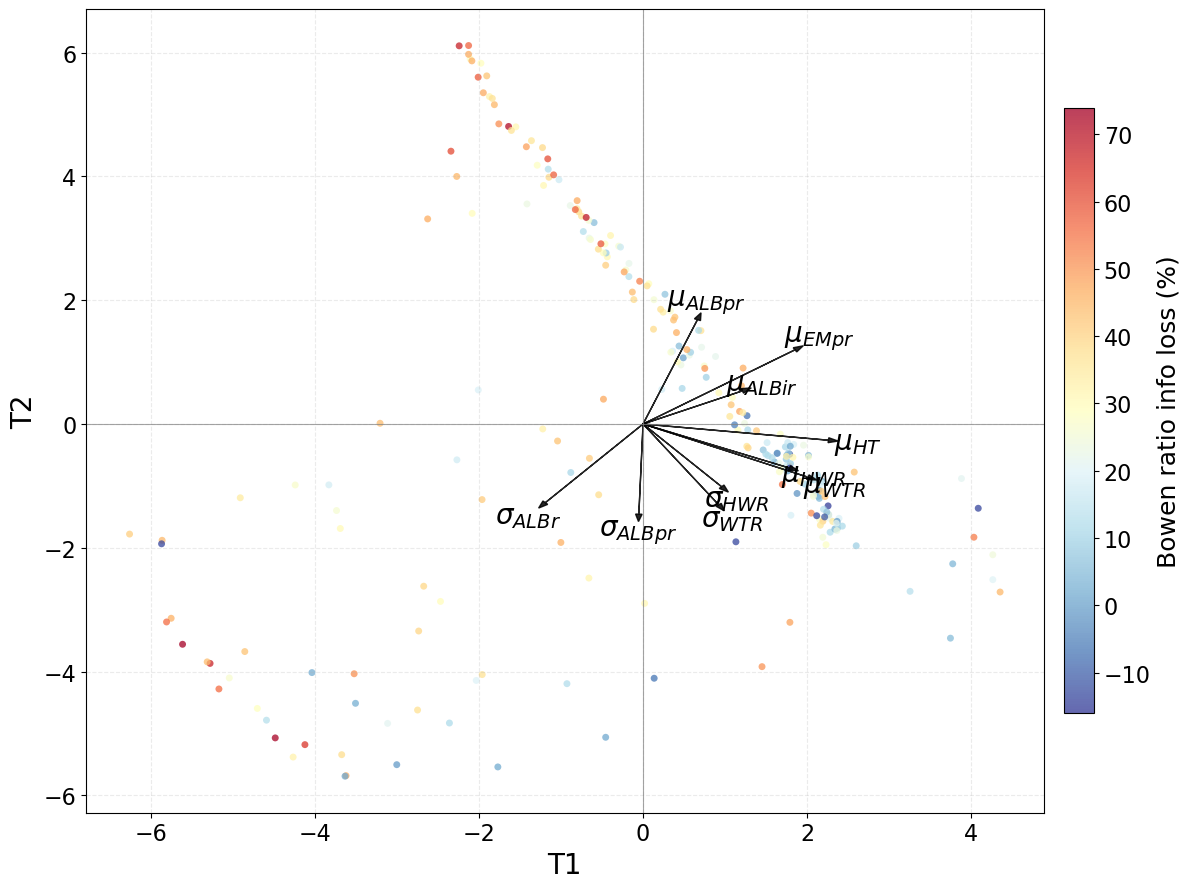

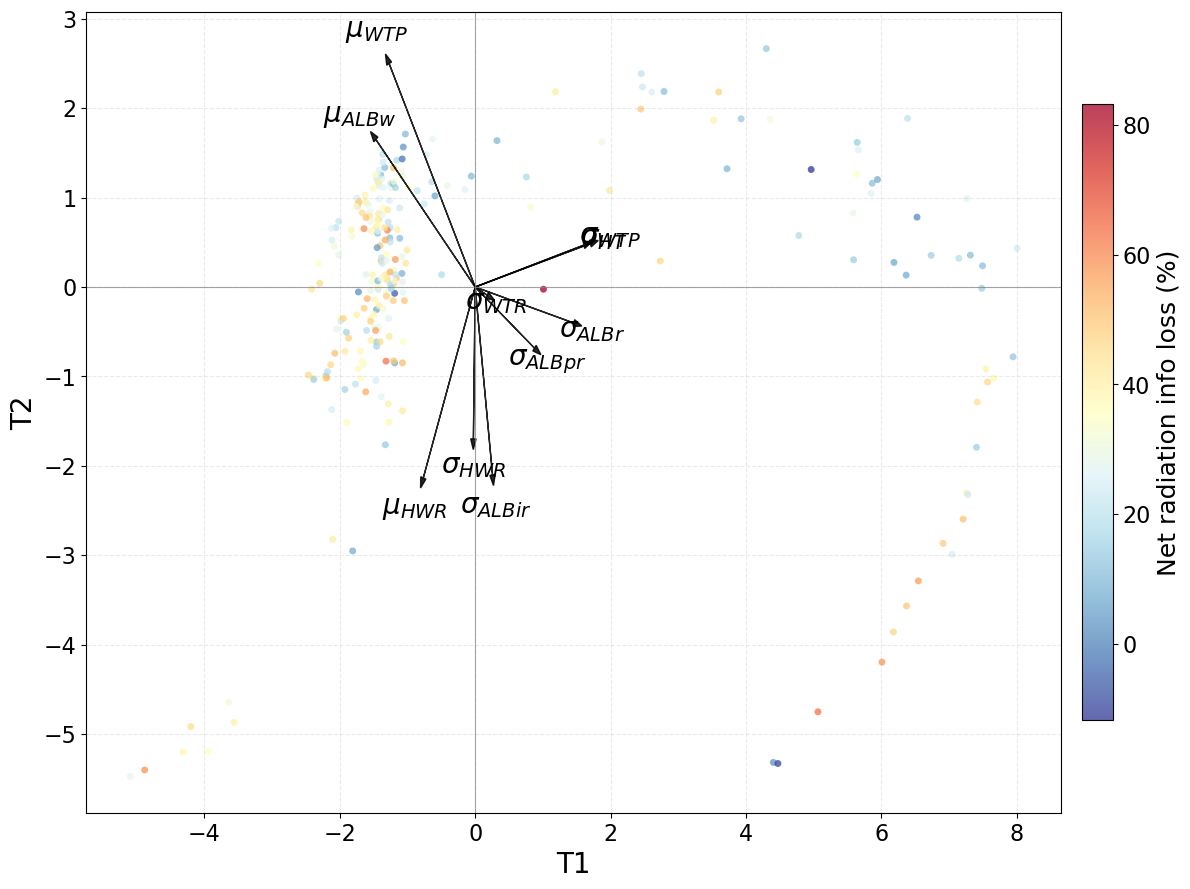

In [8]:
# 5) Conduct PLSR with CV-based component selection to avoid overfitting
pls_results_bowen = perform_pls_cv_analysis(
    pca_df_bowen,
    target_col="avg_info_loss",
    max_components=12,
    n_splits=5,
    random_state=42,
)
pls_results_netrad = perform_pls_cv_analysis(
    pca_df_netrad,
    target_col="avg_info_loss",
    max_components=12,
    n_splits=5,
    random_state=42,
)

compare_br_nr_targets(pca_df_bowen, pca_df_netrad, target_col="avg_info_loss")

print("\nTop PLS drivers for Bowen (by VIP):")
print(pls_results_bowen["coef_df"].head(12))

print("\nTop PLS drivers for NetRad (by VIP):")
print(pls_results_netrad["coef_df"].head(12))

plot_pls_biplot(
    pls_results_bowen,
    target_label="Bowen ratio",
    top_n_loadings=10,
    feature_label_map=feature_label_map,
    save_path="Figure10_CONUS_2deg_PLS_biplot_BR_fixed_VIP.svg",
)

plot_pls_biplot(
    pls_results_netrad,
    target_label="Net radiation",
    top_n_loadings=10,
    feature_label_map=feature_label_map,
    save_path="Figure10_CONUS_2deg_PLS_biplot_NR_fixed_VIP.svg",
)